# Exercise: Computing the variable BMI with MIMIC

We want to create a new variable combining two existing ones. In particular, we want to compute the Body Mass Index (BMI) from two features: the admission Height and Weight measures corresponding to each stay_id from CHARTEVENTS table.

Hints:
- We will need ICUSTAYS table to get the stay_id. We will also need table CHARTEVENTS table to get the Height and Weight measures, and D_ITEMS table to consult the itemid for these measures.
- If we don't merge tables, we can use pandas.DataFrame.loc to look for the itemid corresponding to labels of the admission Height and Weight in D_ITEMS table.
- When looking for these itemid in D_ITEMS, if you do not know the exact label you can look for the strings in column label containing 'Height' and 'Weight' using pandas.Series.str.contains as follows:
> df_ditems.loc[df_ditems.label.str.contains('Height', case=False, na=False, regex=False)]
 
- For the weight, we can use the measures in kilograms (Kg) and pounds (lb) to obtain more stored instances.
- Normalize the height and weight time. Use intime, which provides the date and time the patient was transferred into the ICU, as the reference value to compute the time that has passed since then until the height/weight measurement was taken.
- Try to fill some NaNs using the same information of a given subject_id (different hadm_id and/or stay_id). 
    - For the weight we can use the mean. 
    - For the height we can use the most frequent value (more realistic). 
    - Check how many NaNs are filled.
- After computing the BMI, show the histogram of this new variable.

Please, check also the following:
1. Show that we can have a patient with more than one icustay.
2. Revise the NaNs in the used dataframes.

### Some more details about the tables that we are using in this exercise


**Table ICUSTAYS**:

Table which defines each STAY_ID in the database, i.e. defines a single ICU stay.


**Table CHARTEVENTS**:

Table which contains all charted data for all patients.

Identifiers which specify the patient: SUBJECT_ID is unique to a patient, HADM_ID is unique to a patient hospital stay and STAY_ID is unique to a patient ICU stay.

One of the columns is ITEMID which is the identifier for a single measurement type in the database. Each row associated with one ITEMID (e.g. 212) corresponds to an instantiation of the same measurement (e.g. heart rate).

VALUE contains the value measured for the concept identified by the ITEMID. If this value is numeric, then VALUENUM contains the same data in a numeric format. If this data is not numeric, VALUENUM is null. In some cases (e.g. scores like Glasgow Coma Scale, Richmond Sedation Agitation Scale and Code Status), VALUENUM contains the score and VALUE contains the score and text describing the meaning of the score.


**Table D_ITEMS**:

Dictionary of ITEMIDs appearing in the MIMIC database, except those that relate to laboratory tests (which are stored in D_LABITEMS).

This table defines ITEMID, which represents measurements in the database. 
The ITEMID column is an alternate primary key to this table: it is unique to each row.


In [69]:
# Your solution here
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.ion()

In [70]:
path = "data/mimic-iv-clinical-database-demo-2.2/" #path to the data folder 

In [103]:
# load all the tables
# CHARTEVENTS
df_chartevents = pd.read_csv(path+'icu/chartevents.csv.gz')
# ICUSTAYS
df_icustays = pd.read_csv(path+'icu/icustays.csv.gz')
# D_ITEMS
df_d_items = pd.read_csv(path+'icu/d_items.csv.gz')
# patients
df_patients = pd.read_csv(path+'hosp/patients.csv.gz')

In [72]:
df_chartevents.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,225054,On,NaN,NaN,0.0
1,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:43:00,223769,100,100.0,%,0.0
2,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,223956,Atrial demand,NaN,NaN,0.0
3,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224866,Yes,NaN,NaN,0.0
4,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,227341,No,0.0,NaN,0.0


In [73]:
df_icustays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


In [74]:
df_d_items.head()

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,226228,Gender,Gender,chartevents,ADT,NaN,Text,NaN,NaN
1,226545,Race,Race,chartevents,ADT,NaN,Text,NaN,NaN
2,229877,Suction events (CH),Suction events (CH),chartevents,ECMO,NaN,Text,NaN,NaN
3,229875,Oxygenator visible (CH),Oxygenator visible (CH),chartevents,ECMO,NaN,Text,NaN,NaN
4,229266,Cannula sites visually inspected (ECMO),Cannula sites visually inspected (ECMO),chartevents,ECMO,NaN,Text,NaN,NaN


In [75]:
# get the itemid for height and weight using regex
height_itemid = df_d_items[df_d_items['label'].str.contains('height', case=False, regex=True)]['itemid'].values
weight_itemid = df_d_items[df_d_items['label'].str.contains('weight', case=False, regex=True)]['itemid'].values
print(f"Height itemid: {height_itemid}")
print(f"Weight itemid: {weight_itemid}")

Height itemid: [226707 226730]
Weight itemid: [227854 226742 226740 226741 226846 226531 226512 224639 225124]


In [76]:
for itemid in height_itemid:
    print(df_d_items[df_d_items['itemid'] == itemid]['label'].values[0])

Height
Height (cm)


In [77]:
for itemid in weight_itemid:
    print(df_d_items[df_d_items['itemid'] == itemid]['label'].values[0])

Weight Bearing Status
APACHE II Diagnosistic weight factors - Surgical
APACHE II Diagnosistic weight factors - Medical
APACHE II Diagnosistic weight factors - Surgical emergency
Feeding Weight
Admission Weight (lbs.)
Admission Weight (Kg)
Daily Weight
Unintentional weight loss >10 lbs.


In [78]:
itemid_height_unk_units = 226707
itemid_height_prob_cm = 226730
itemid_weight_prob_lbs = 226531
itemid_weight_prob_kg = 226512
itemid_weight_unk_daily_units = 224639
# create a dictionary to store itemid and their corresponding explanation
itemid_explanation = {
    itemid_height_unk_units: "Height with unknown units",
    itemid_height_prob_cm: "Height probably in centimeters",
    itemid_weight_prob_lbs: "Weight probably in pounds",
    itemid_weight_prob_kg: "Weight probably in kilograms",
    itemid_weight_unk_daily_units: "Weight with unknown daily units"
}

In [79]:
# there are two possible itemids for height: Height (cm), Height (unk. units)
# there are three possible itemids for weight: Admission Weight (lbs.), Admission Weight (Kg), Daily Weight
# as data always has problems, we will suspect from this units from a start
# first, filter the chartevents for these itemids
df_chartevents['itemid_explanation'] = df_chartevents['itemid'].map(itemid_explanation)
df_height = df_chartevents[df_chartevents['itemid'].isin([itemid_height_unk_units, itemid_height_prob_cm])]
df_weight = df_chartevents[df_chartevents['itemid'].isin([itemid_weight_prob_lbs, itemid_weight_prob_kg, itemid_weight_unk_daily_units])]

In [80]:
df_height.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation
2715,10005817,20626031,32604416,65197.0,2132-12-15 09:29:00,2132-12-15 10:11:00,226707,68,68.0,Inch,0.0,Height with unknown units
2716,10005817,20626031,32604416,65197.0,2132-12-15 09:29:00,2132-12-15 10:11:00,226730,173,173.0,cm,0.0,Height probably in centimeters
4282,10027445,29163082,36084484,54375.0,2142-08-30 13:20:00,2142-08-30 21:27:00,226707,63,63.0,Inch,0.0,Height with unknown units
4283,10027445,29163082,36084484,54375.0,2142-08-30 13:20:00,2142-08-30 21:27:00,226730,160,160.0,cm,0.0,Height probably in centimeters
6529,10005348,25239799,34629895,28451.0,2130-10-27 12:06:00,2130-10-27 16:58:00,226707,73,73.0,Inch,0.0,Height with unknown units


In [81]:
df_weight.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation
147,10005817,20626031,32604416,6770.0,2132-12-16 04:00:00,2132-12-16 04:17:00,224639,95.1,95.1,kg,0.0,Weight with unknown daily units
2374,10005817,20626031,32604416,65197.0,2132-12-15 10:10:00,2132-12-15 10:11:00,226531,200.2,200.2,NaN,0.0,Weight probably in pounds
2717,10005817,20626031,32604416,65197.0,2132-12-15 09:29:00,2132-12-15 10:11:00,226512,91,91.0,kg,0.0,Weight probably in kilograms
3495,10027445,29163082,36084484,54375.0,2142-08-30 16:00:00,2142-08-30 20:10:00,224639,103,103.0,kg,0.0,Weight with unknown daily units
3861,10027445,29163082,36084484,54375.0,2142-08-31 06:00:00,2142-08-31 06:23:00,224639,98.6,98.6,kg,0.0,Weight with unknown daily units


In [82]:
# visualize stay_id 32604416
stay_id = 32604416
height_stay = df_height[df_height['stay_id'] == stay_id]
weight_stay = df_weight[df_weight['stay_id'] == stay_id]
icu_stay = df_icustays[df_icustays['stay_id'] == stay_id]

In [83]:
height_stay

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation
2715,10005817,20626031,32604416,65197.0,2132-12-15 09:29:00,2132-12-15 10:11:00,226707,68,68.0,Inch,0.0,Height with unknown units
2716,10005817,20626031,32604416,65197.0,2132-12-15 09:29:00,2132-12-15 10:11:00,226730,173,173.0,cm,0.0,Height probably in centimeters


In [84]:
weight_stay

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation
147,10005817,20626031,32604416,6770.0,2132-12-16 04:00:00,2132-12-16 04:17:00,224639,95.1,95.1,kg,0.0,Weight with unknown daily units
2374,10005817,20626031,32604416,65197.0,2132-12-15 10:10:00,2132-12-15 10:11:00,226531,200.2,200.2,NaN,0.0,Weight probably in pounds
2717,10005817,20626031,32604416,65197.0,2132-12-15 09:29:00,2132-12-15 10:11:00,226512,91,91.0,kg,0.0,Weight probably in kilograms


In [85]:
icu_stay

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
112,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097


In [86]:
# from df_icustays, we can extract the admission time for each stay_id (only yyyy-mm-dd)
# Then we filter the chartevents to only keep height and weight measurements that were taken within the first 24 hours of the admission time 
# with storetime
df_icustays['intime'] = pd.to_datetime(df_icustays['intime'])
df_icustays['intime_date'] = df_icustays['intime'].dt.date
df_height['storetime'] = pd.to_datetime(df_height['storetime'])
df_weight['storetime'] = pd.to_datetime(df_weight['storetime'])
df_height['storetime_date'] = df_height['storetime'].dt.date
df_weight['storetime_date'] = df_weight['storetime'].dt.date

/tmp/ipykernel_518438/2681622838.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_height['storetime'] = pd.to_datetime(df_height['storetime'])
/tmp/ipykernel_518438/2681622838.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_weight['storetime'] = pd.to_datetime(df_weight['storetime'])
/tmp/ipykernel_518438/2681622838.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

In [87]:
# store the intime_date for each stay_id in a dictionary
stay_id_intime_date = dict(zip(df_icustays['stay_id'], df_icustays['intime_date']))
# and create a new column in df_height and df_weight with the intime_date for each stay_id
df_height['intime_date'] = df_height['stay_id'].map(stay_id_intime_date)
df_weight['intime_date'] = df_weight['stay_id'].map(stay_id_intime_date)
df_height

/tmp/ipykernel_518438/242447766.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_height['intime_date'] = df_height['stay_id'].map(stay_id_intime_date)
/tmp/ipykernel_518438/242447766.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_weight['intime_date'] = df_weight['stay_id'].map(stay_id_intime_date)


,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation,storetime_date,intime_date
2715,10005817,20626031,32604416,65197.0,2132-12-15 09:29:00,2132-12-15 10:11:00,226707,68,68.0,Inch,0.0,Height with unknown units,2132-12-15,2132-12-15
2716,10005817,20626031,32604416,65197.0,2132-12-15 09:29:00,2132-12-15 10:11:00,226730,173,173.0,cm,0.0,Height probably in centimeters,2132-12-15,2132-12-15
4282,10027445,29163082,36084484,54375.0,2142-08-30 13:20:00,2142-08-30 21:27:00,226707,63,63.0,Inch,0.0,Height with unknown units,2142-08-30,2142-08-30
4283,10027445,29163082,36084484,54375.0,2142-08-30 13:20:00,2142-08-30 21:27:00,226730,160,160.0,cm,0.0,Height probably in centimeters,2142-08-30,2142-08-30
6529,10005348,25239799,34629895,28451.0,2130-10-27 12:06:00,2130-10-27 16:58:00,226707,73,73.0,Inch,0.0,Height with unknown units,2130-10-27,2130-10-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641651,10003400,23559586,38383343,36212.0,2137-08-10 19:54:00,2137-08-17 21:21:00,226707,65,65.0,Inch,0.0,Height with unknown units,2137-08-17,2137-08-17
649944,10018081,28861356,38333427,34445.0,2134-08-05 14:53:00,2134-08-07 14:19:00,226730,173,173.0,cm,0.0,Height probably in centimeters,2134-08-07,2134-08-05
649945,10018081,28861356,38333427,34445.0,2134-08-05 14:53:00,2134-08-07 14:19:00,226707,68,68.0,Inch,0.0,Height with unknown units,2134-08-07,2134-08-05
668000,10019003,29279905,34107647,68979.0,2153-03-27 23:26:00,2153-03-28 03:12:00,226707,64,64.0,Inch,0.0,Height with unknown units,2153-03-28,2153-03-28


In [88]:
# group by stay_id and keep only the first height measurement based on storetime value for each stay_id, do the same for weight
df_height_first = df_height.sort_values('storetime').groupby('stay_id').first().reset_index()
df_weight_first = df_weight.sort_values('storetime').groupby('stay_id').first().reset_index()
# check nan height and weight measurements
print(f"Number of height measurements with NaN value: {df_height_first['valuenum'].isna().sum()}")
print(f"Number of weight measurements with NaN value: {df_weight_first['valuenum'].isna().sum()}")
# check rows where storetime_date does not match intime_date
print(f"Number of height measurements with storetime_date not matching intime_date: {df_height_first[df_height_first['storetime_date'] != df_height_first['intime_date']].shape[0]}")
print(f"Number of weight measurements with storetime_date not matching intime_date: {df_weight_first[df_weight_first['storetime_date'] != df_weight_first['intime_date']].shape[0]}")

Number of height measurements with NaN value: 0
Number of weight measurements with NaN value: 0
Number of height measurements with storetime_date not matching intime_date: 28
Number of weight measurements with storetime_date not matching intime_date: 10


In [89]:
# we don't have a problem with NaN values, but we have a problem with measurements taken on a different day than the admission day
# which means that we cannot be sure that these measurements were taken within the first 24 hours of the admission time.
# Can only use .dt accessor with datetimelike values, so we need to convert the date columns to datetime first
df_height_first['storetime_date'] = pd.to_datetime(df_height_first['storetime_date'])
df_height_first['intime_date'] = pd.to_datetime(df_height_first['intime_date'])
df_weight_first['storetime_date'] = pd.to_datetime(df_weight_first['storetime_date'])
df_weight_first['intime_date'] = pd.to_datetime(df_weight_first['intime_date'])
diff_in_hours_height = (df_height_first['storetime_date'] - df_height_first['intime_date']).dt.total_seconds() / 3600
diff_in_hours_weight = (df_weight_first['storetime_date'] - df_weight_first['intime_date']).dt.total_seconds() / 3600
print(f"Max difference in hours between storetime_date and intime_date for height measurements: {diff_in_hours_height.max()}")
print(f"Max difference in hours between storetime_date and intime_date for weight measurements: {diff_in_hours_weight.max()}")

Max difference in hours between storetime_date and intime_date for height measurements: 384.0
Max difference in hours between storetime_date and intime_date for weight measurements: 48.0


In [90]:
# I would say that to fill the NaN values it's better to keep the most proximal measurement to the admission time,
# not do imputation with the mean or median
# I know the exercise is to do imputation, but I would leave the approximations as they are right now because the diff in hours is not
# that big for measurements like height and weight, which are not expected to change that much within the first days of admission.
df_height_first

,stay_id,subject_id,hadm_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation,storetime_date,intime_date
0,30057454,10023117,28872262,96730.0,2171-11-14 10:06:00,2171-11-14 10:08:00,226707,67,67.0,Inch,0.0,Height with unknown units,2171-11-14,2171-11-14
1,30101877,10032725,20611640,34064.0,2143-03-22 05:00:00,2143-03-24 11:53:00,226730,183,183.0,cm,0.0,Height probably in centimeters,2143-03-24,2143-03-22
2,30425410,10016742,27568122,3512.0,2178-07-22 07:20:00,2178-07-22 14:25:00,226707,65,65.0,Inch,0.0,Height with unknown units,2178-07-22,2178-07-22
3,30585761,10022281,29642388,28029.0,2125-06-17 04:12:00,2125-06-17 05:05:00,226730,170,170.0,cm,0.0,Height probably in centimeters,2125-06-17,2125-06-17
4,30665396,10018423,29366372,65197.0,2167-05-05 12:54:00,2167-05-05 14:53:00,226730,170,170.0,cm,0.0,Height probably in centimeters,2167-05-05,2167-05-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,39553978,10000032,29079034,88981.0,2180-07-23 12:36:00,2180-07-23 14:45:00,226730,152,152.0,cm,0.0,Height probably in centimeters,2180-07-23,2180-07-23
67,39635619,10004733,27411876,34445.0,2174-12-04 11:28:00,2174-12-10 11:57:00,226730,180,180.0,cm,0.0,Height probably in centimeters,2174-12-10,2174-12-04
68,39711498,10038999,27189241,55302.0,2131-05-22 21:50:00,2131-05-22 22:37:00,226707,70,70.0,Inch,0.0,Height with unknown units,2131-05-22,2131-05-22
69,39804682,10037928,24656677,17492.0,2178-12-21 06:05:00,2178-12-21 09:11:00,226707,60,60.0,Inch,0.0,Height with unknown units,2178-12-21,2178-12-21


In [91]:
# check all unique valueuom in height and weight measurements
print(f"Unique valueuom in height measurements: {df_height_first['valueuom'].unique()}")
print(f"Unique valueuom in weight measurements: {df_weight_first['valueuom'].unique()}")
# check rows with empty valueuom in height and weight measurements
print(f"Number of height measurements with empty valueuom: {df_height_first['valueuom'].isna().sum()}")
print(f"Number of weight measurements with empty valueuom: {df_weight_first['valueuom'].isna().sum()}")
# see row with empty valueuom in weight measurements
df_weight_first[df_weight_first['valueuom'].isna()] # probably in pounds from the itemid_explanation, so change valueuom to lb
df_weight_first.loc[df_weight_first['valueuom'].isna(), 'valueuom'] = 'lb'
print(f"Number of weight measurements with empty valueuom after filling: {df_weight_first['valueuom'].isna().sum()}")

Unique valueuom in height measurements: ['Inch' 'cm']
Unique valueuom in weight measurements: ['kg' None]
Number of height measurements with empty valueuom: 0
Number of weight measurements with empty valueuom: 1
Number of weight measurements with empty valueuom after filling: 0


In [93]:
"""
itemid_height_unk_units: "Height with unknown units",
itemid_height_prob_cm: "Height probably in centimeters",
itemid_weight_prob_lbs: "Weight probably in pounds",
itemid_weight_prob_kg: "Weight probably in kilograms",
itemid_weight_unk_daily_units: "Weight with unknown daily units"
"""
# check if there are inconsistencies between itemid_explanation and valueuom columns in height and weight measurements
print(f"Number of height measurements with inconsistency in centimeters: {df_height_first[df_height_first['itemid_explanation'].str.contains('centimeters') & (df_height_first['valueuom'] != 'cm')].shape[0]}")
print(f"Number of weight measurements with inconsistency in pounds: {df_weight_first[df_weight_first['itemid_explanation'].str.contains('pounds') & (df_weight_first['valueuom'] != 'lb')].shape[0]}")
print(f"Number of weight measurements with inconsistency in kilograms: {df_weight_first[df_weight_first['itemid_explanation'].str.contains('kilograms') & (df_weight_first['valueuom'] != 'kg')].shape[0]}")

Number of height measurements with inconsistency in centimeters: 0
Number of weight measurements with inconsistency in pounds: 43
Number of weight measurements with inconsistency in kilograms: 0


In [ ]:
# check inconsistencies in pounds
# pound accepted range [50, 500] lb
# kilogram accepted range [20, 300] kg
pound_inconsistencies = df_weight_first[df_weight_first['itemid_explanation'].str.contains('pounds') & (df_weight_first['valueuom'] != 'lb')]
pound_inconsistencies # all units are reported in kg but the itemid_explanation says that they are in pounds

,stay_id,subject_id,hadm_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation,storetime_date,intime_date
3,30458995,10031757,28477280,55876.0,2137-10-13 03:21:00,2137-10-13 03:22:00,226531,257.4,257.4,kg,0.0,Weight probably in pounds,2137-10-13,2137-10-12
4,30585761,10022281,29642388,28029.0,2125-06-17 05:05:00,2125-06-17 05:05:00,226531,180,180.0,kg,0.0,Weight probably in pounds,2125-06-17,2125-06-17
6,30757476,10020944,29974575,34175.0,2131-02-27 17:36:00,2131-02-27 17:40:00,226531,237.6,237.6,kg,0.0,Weight probably in pounds,2131-02-27,2131-02-27
8,30864406,10026406,25260176,66056.0,2129-01-05 02:45:00,2129-01-05 02:45:00,226531,170.9,170.9,kg,0.0,Weight probably in pounds,2129-01-05,2129-01-05
12,30955999,10023117,21607814,94254.0,2175-07-06 17:53:00,2175-07-06 17:53:00,226531,152.7,152.7,kg,0.0,Weight probably in pounds,2175-07-06,2175-07-06
13,31077365,10020740,23831430,64480.0,2150-03-30 15:42:00,2150-03-30 15:42:00,226531,226.6,226.6,kg,0.0,Weight probably in pounds,2150-03-30,2150-03-30
14,31205490,10001725,25563031,22280.0,2110-04-11 16:01:00,2110-04-11 16:01:00,226531,158.8,158.8,kg,0.0,Weight probably in pounds,2110-04-11,2110-04-11
15,31248398,10026255,22059910,54375.0,2201-07-07 19:09:00,2201-07-07 19:52:00,226531,150.9,150.9,kg,0.0,Weight probably in pounds,2201-07-07,2201-07-07
17,31316840,10005817,28661809,1215.0,2135-01-03 22:02:00,2135-01-03 22:02:00,226531,195.4,195.4,kg,0.0,Weight probably in pounds,2135-01-03,2135-01-03
19,31494479,10004457,23251352,53913.0,2141-12-17 12:18:00,2141-12-17 14:55:00,226531,149.6,149.6,kg,0.0,Weight probably in pounds,2141-12-17,2141-12-17


In [ ]:
# for this cases in pound_inconsistencies, we can check other weight measurements for the same stay_id to see if they are consistent with pounds or kilograms, and then we can fill the valueuom accordingly
unique_subject_ids = pound_inconsistencies['subject_id'].unique()
for subject_id in unique_subject_ids:
    # check for values in df_weight for the same subject_id and see if there are any measurements with valueuom in lb or kg
    weight_measurements = df_weight[df_weight['subject_id'] == subject_id]
    if (weight_measurements['valueuom'] == 'lb').any():
        print(f"Subject_id {subject_id} has measurements at least one measurement in pounds")

# TODO: all measurements are reported in kg, we will assume that the valueuom is more accurate than the itemid_explanation
# but we should ask the professor about this to discuss how to handle it

In [98]:
# we can guide us with valueuom units then
# convert all Inch measurements to cm and all lb measurements to kg, then we can calculate BMI with the formula: BMI = weight (kg) / (height (m))^2
df_height_first.loc[df_height_first['valueuom'] == 'Inch', 'valuenum'] = df_height_first.loc[df_height_first['valueuom'] == 'Inch', 'valuenum'] * 2.54
df_height_first.loc[df_height_first['valueuom'] == 'Inch', 'valueuom'] = 'cm'
df_weight_first.loc[df_weight_first['valueuom'] == 'lb', 'valuenum'] = df_weight_first.loc[df_weight_first['valueuom'] == 'lb', 'valuenum'] * 0.453592
df_weight_first.loc[df_weight_first['valueuom'] == 'lb', 'valueuom'] = 'kg'

In [99]:
# check that all height measurements are in cm and all weight measurements are in kg
print(f"Unique valueuom in height measurements after conversion: {df_height_first['valueuom'].unique()}")
print(f"Unique valueuom in weight measurements after conversion: {df_weight_first['valueuom'].unique()}")

Unique valueuom in height measurements after conversion: ['cm']
Unique valueuom in weight measurements after conversion: ['kg']


In [100]:
# yay!
# now search for outliers in height and weight measurements, we can use the accepted ranges for height and weight to identify outliers
# height accepted range [100, 250] cm
# weight accepted range [20, 300] kg
height_outliers = df_height_first[(df_height_first['valueuom'] == 'cm') & ((df_height_first['valuenum'] < 100) | (df_height_first['valuenum'] > 250))]
weight_outliers = df_weight_first[(df_weight_first['valueuom'] == 'kg') & ((df_weight_first['valuenum'] < 20) | (df_weight_first['valuenum'] > 300))]
print(f"Number of height outliers: {height_outliers.shape[0]}")
print(f"Number of weight outliers: {weight_outliers.shape[0]}")

Number of height outliers: 2
Number of weight outliers: 1


In [101]:
# inspect those outliers to see if they are really outliers or if they are just errors in the units that we can fix
height_outliers

,stay_id,subject_id,hadm_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation,storetime_date,intime_date
35,34617352,10006053,22942076,8549.0,2111-11-14 00:19:00,2111-11-15 15:10:00,226707,28,71.12,cm,0.0,Height with unknown units,2111-11-15,2111-11-14
61,38559363,10039708,23819016,82093.0,2140-06-18 00:23:00,2140-06-18 01:44:00,226707,24,60.96,cm,0.0,Height with unknown units,2140-06-18,2140-06-18


In [108]:
# for height, they could be children, we can check the age of the patients with height outliers to see if they are children or not
# load the patients table to get the age of the patients
# from subject_id table df_patients we can get the anchor_age
for subject_id in height_outliers['subject_id'].unique():
    age = df_patients[df_patients['subject_id'] == subject_id]['anchor_age'].values[0]
    print(f"Subject_id {subject_id} has age {age}")
# Subject_id 10006053 has age 52
# Subject_id 10039708 has age 46
# impossible!
# check its height assuming that the valueuom is in inches and convert it to cm
height_outliers_inch = height_outliers.copy()
height_outliers_inch['valuenum'] = height_outliers_inch['valuenum'] * 2.54
height_outliers_inch['valueuom'] = 'cm'
print(f"Subject outliers height in cm assuming that the valueuom is in inches: {height_outliers_inch['valuenum'].values}")
# 180.6448
# 154.8384
# this is more reasonable, we can assume that the valueuom for these two patients is in inches and convert it to cm
df_height_first.loc[df_height_first['stay_id'].isin(height_outliers['stay_id']), 'valuenum'] = df_height_first.loc[df_height_first['stay_id'].isin(height_outliers['stay_id']), 'valuenum'] * 2.54
df_height_first.loc[df_height_first['stay_id'].isin(height_outliers['stay_id']), 'valueuom'] = 'cm'

Subject_id 10006053 has age 52
Subject_id 10039708 has age 46
Subject outliers height in cm assuming that the valueuom is in inches: [180.6448 154.8384]


In [109]:
# check for height outliers again after fixing the units
height_outliers = df_height_first[(df_height_first['valueuom'] == 'cm') & ((df_height_first['valuenum'] < 100) | (df_height_first['valuenum'] > 250))]
print(f"Number of height outliers after fixing the units: {height_outliers.shape[0]}")

Number of height outliers after fixing the units: 0


In [ ]:
weight_outliers # this is a patient without weight measurements
# weight = 0.0 for subject_id 10029484

,stay_id,subject_id,hadm_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation,storetime_date,intime_date
72,35396193,10029484,20764029,99720.0,2160-11-08 05:34:00,2160-11-08 05:34:00,226531,0,0.0,kg,0.0,Weight probably in pounds,2160-11-08,2160-11-08


In [ ]:
# we can check if there are other weight measurements for the same subject_id to see if we can fill the valueuom and the valuenum for this patient
subject_id = 10029484
intime_date = "2160-11-08"
# check for weight measurements for the same subject_id with proximal storetime_date to the intime_date
weight_measurements_subject = df_weight[df_weight['subject_id'] == subject_id]
weight_measurements_subject # there are multiple weight measurements for the same admission day in kg -> substitute the value for 90.0 and kg

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,itemid_explanation,storetime_date,intime_date
248517,10029484,20764029,35396193,99720.0,2160-11-08 04:16:00,2160-11-08 06:23:00,226512,90,90.0,kg,0.0,Weight probably in kilograms,2160-11-08,2160-11-08
248524,10029484,20764029,35396193,99720.0,2160-11-08 06:22:00,2160-11-08 06:23:00,226531,198,198.0,NaN,0.0,Weight probably in pounds,2160-11-08,2160-11-08
248546,10029484,20764029,35396193,27635.0,2160-11-08 16:30:00,2160-11-08 16:30:00,226531,198,198.0,NaN,0.0,Weight probably in pounds,2160-11-08,2160-11-08
248567,10029484,20764029,35396193,99720.0,2160-11-08 05:34:00,2160-11-08 05:34:00,226531,0,0.0,NaN,0.0,Weight probably in pounds,2160-11-08,2160-11-08
248580,10029484,20764029,35396193,99720.0,2160-11-08 05:39:00,2160-11-08 05:40:00,226531,198,198.0,NaN,0.0,Weight probably in pounds,2160-11-08,2160-11-08


In [113]:
df_weight_first.loc[df_weight_first['subject_id'] == subject_id, 'valuenum'] = 90.0
df_weight_first.loc[df_weight_first['subject_id'] == subject_id, 'valueuom'] = 'kg'
# check for weight outliers again after filling the value for subject_id 10029484
weight_outliers = df_weight_first[(df_weight_first['valueuom'] == 'kg') & ((df_weight_first['valuenum'] < 20) | (df_weight_first['valuenum'] > 300))]
print(f"Number of weight outliers after filling the value for subject_id 10029484: {weight_outliers.shape[0]}")

Number of weight outliers after filling the value for subject_id 10029484: 0


In [123]:
# now we have clean data to calculate the BMI for each stay_id with the formula: BMI = weight (kg) / (height (m))^2
# first, we need to merge the height and weight dataframes on stay_id to have the height and weight measurements in the same dataframe
df_bmi = pd.merge(df_height_first[['subject_id', 'stay_id', 'valuenum', 'valueuom']], df_weight_first[['subject_id', 'stay_id', 'valuenum', 'valueuom']], on=['subject_id', 'stay_id'], suffixes=('_height', '_weight'))
df_bmi.head()

,subject_id,stay_id,valuenum_height,valueuom_height,valuenum_weight,valueuom_weight
0,10023117,30057454,170.18,cm,86.2,kg
1,10032725,30101877,183.00,cm,83.3,kg
2,10016742,30425410,165.10,cm,60.0,kg
3,10022281,30585761,170.00,cm,180.0,kg
4,10018423,30665396,170.00,cm,107.0,kg


In [124]:
# now we can add a new column for BMI with the formula: BMI = weight (kg) / (height (cm))^2 * 10000 (to convert cm to m)
df_bmi['bmi'] = df_bmi['valuenum_weight'] / (df_bmi['valuenum_height'] ** 2) * 10000
df_bmi

,subject_id,stay_id,valuenum_height,valueuom_height,valuenum_weight,valueuom_weight,bmi
0,10023117,30057454,170.18,cm,86.2,kg,29.763927
1,10032725,30101877,183.00,cm,83.3,kg,24.873839
2,10016742,30425410,165.10,cm,60.0,kg,22.011878
3,10022281,30585761,170.00,cm,180.0,kg,62.283737
4,10018423,30665396,170.00,cm,107.0,kg,37.024221
...,...,...,...,...,...,...,...
66,10000032,39553978,152.00,cm,86.7,kg,37.525970
67,10004733,39635619,180.00,cm,112.5,kg,34.722222
68,10038999,39711498,177.80,cm,98.9,kg,31.284756
69,10037928,39804682,152.40,cm,68.0,kg,29.277836


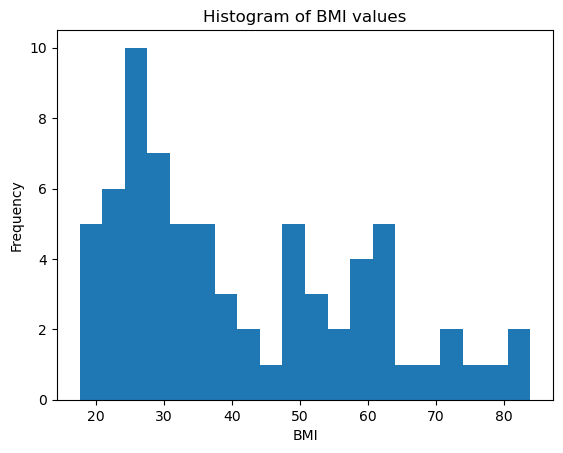

In [125]:
# show the histogram of the BMI values
plt.hist(df_bmi['bmi'], bins=20)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('Histogram of BMI values')
plt.show()

In [135]:
# check that we can have patients with multiple icu stays
subject_id_stay_id = df_icustays.groupby('subject_id')['stay_id'].apply(list).reset_index()
subject_id_stay_id = subject_id_stay_id[subject_id_stay_id['stay_id'].apply(len) > 1]
subject_id_stay_id

,subject_id,stay_id
1,10001217,"[37067082, 34592300]"
3,10002428,"[34807493, 38875437, 33987268, 35479615]"
5,10002930,"[37049133, 35629889]"
7,10003400,"[38383343, 34577403, 32128372]"
14,10005817,"[32604416, 31316840]"
17,10006053,"[34617352, 32895909]"
35,10014354,"[38017367, 37200209, 34600477, 39864867]"
38,10015860,"[32496174, 36734659]"
39,10015931,"[39544395, 38137964, 37093652]"
41,10016742,"[32314488, 30425410, 37057036]"


In [137]:
# do the same for the df_bmi dataframe to see if we have patients with multiple BMI measurements due to multiple icu stays
subject_id_stay_id_bmi = df_bmi.groupby('subject_id')['stay_id'].apply(list).reset_index()
subject_id_stay_id_bmi = subject_id_stay_id_bmi[subject_id_stay_id_bmi['stay_id'].apply(len) > 1]
subject_id_stay_id_bmi

,subject_id,stay_id
2,10002428,"[33987268, 34807493]"
5,10003400,"[32128372, 38383343]"
12,10005817,"[31316840, 32604416]"
26,10016742,"[30425410, 32314488]"
27,10018081,"[37293400, 38333427]"
30,10019003,"[34107647, 35727289]"
42,10023117,"[30057454, 30955999, 38554095]"
46,10027445,"[34499716, 36084484]"
47,10027602,"[32391858, 32453351]"
58,10039708,"[33281088, 38559363]"


In [ ]:
# focus on subject_id 10002428
# get all the values of different stay_id
stays_subject_10002428 = df_icustays[df_icustays['subject_id'] == 10002428][['stay_id', 'intime']]
print(stays_subject_10002428)
# check the weight and height measurements for each stay_id for this subject_id
for stay_id in stays_subject_10002428['stay_id']:
    height_stay = df_height[df_height['stay_id'] == stay_id]
    weight_stay = df_weight[df_weight['stay_id'] == stay_id]
    print(f"Stay_id {stay_id} has height measurements: {height_stay[['valuenum', 'valueuom']]}")
    print(f"Stay_id {stay_id} has weight measurements: {weight_stay[['valuenum', 'valueuom']]}")

# TODO: ask teacher. We are only computing BMI for those stays in which we have at least one height and one weight.

     stay_id               intime
35  34807493  2156-04-30 21:53:00
38  38875437  2156-04-19 18:11:19
53  33987268  2156-04-12 16:24:18
62  35479615  2156-05-11 14:49:34
Stay_id 34807493 has height measurements:         valuenum valueuom
510848     150.0       cm
510849      59.0     Inch
Stay_id 34807493 has weight measurements:         valuenum valueuom
510419     121.0      NaN
510838     121.0      NaN
510847      55.0       kg
510851     121.0      NaN
511099     121.0      NaN
Stay_id 38875437 has height measurements: Empty DataFrame
Columns: [valuenum, valueuom]
Index: []
Stay_id 38875437 has weight measurements:        valuenum valueuom
83574      64.4       kg
84371      94.6      NaN
85329      43.0       kg
85547      94.6      NaN
85910      94.6      NaN
86561      94.6      NaN
86903      94.6      NaN
Stay_id 33987268 has height measurements:         valuenum valueuom
503219     150.0       cm
503220      59.0     Inch
Stay_id 33987268 has weight measurements:         va